In [1]:
# ============================================================
# IMPORTS
# ============================================================

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_DIR = "/content/drive/MyDrive/exoplanet_pipeline/data"
REPORT_DIR = "/content/drive/MyDrive/exoplanet_pipeline/reports"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

STAGE1_PATH = os.path.join(DATA_DIR, "stage1_output.pkl")
STAGE2_PATH = os.path.join(DATA_DIR, "stage2_output.pkl")
STAGE3_PATH = os.path.join(DATA_DIR, "stage3_output.pkl")
STAGE5_PATH = os.path.join(DATA_DIR, "stage5_output.pkl")
STAGE6_PATH = os.path.join(DATA_DIR, "stage6_output.pkl")
STAGE7_PATH = os.path.join(DATA_DIR, "stage7_output.pkl")
STAGE8_PATH = os.path.join(DATA_DIR, "stage8_output.pkl")

print("Paths configured.")

Paths configured.


In [4]:
with open(STAGE1_PATH, "rb") as f:
    stage1 = pickle.load(f)

with open(STAGE2_PATH, "rb") as f:
    stage2 = pickle.load(f)

with open(STAGE3_PATH, "rb") as f:
    stage3 = pickle.load(f)

with open(STAGE5_PATH, "rb") as f:
    stage5 = pickle.load(f)

with open(STAGE6_PATH, "rb") as f:
    stage6 = pickle.load(f)

with open(STAGE7_PATH, "rb") as f:
    stage7 = pickle.load(f)

print("All stages loaded successfully.")
print("Stage 1 keys:", list(stage1.keys()))
print("Stage 5 keys:", list(stage5.keys()))
print("Stage 6 keys:", list(stage6.keys()))
print("Stage 7 keys:", list(stage7.keys()))

All stages loaded successfully.
Stage 1 keys: ['time', 'flux', 'flux_err', 'tic_id', 'crowdsap', 'ra', 'dec', 'gaia_blend_risk', 'gaia_contamination_level', 'gaia_query_success', 'gaia_flag', 'gaia_nearby_stars_count', 'gaia_match_distance_arcsec', 'gaia_match_quality', 'gaia_neighbor_flux_ratio']
Stage 5 keys: ['tic_id', 'ra', 'dec', 'crowdsap', 'period', 'duration', 't0', 'physics_score', 'forensic_score', 'approx_fpp', 'bayesian_fpp', 'planet_probability', 'confidence', 'classification', 'centroid_shift', 'centroid_score', 'centroid_flag', 'pixel_offset', 'pixel_score', 'blend_risk', 'blend_risk_flag', 'tpf_available', 'physics_metrics', 'advanced_metrics', 'weights', 'interpretation', 'strengths', 'concerns']
Stage 6 keys: ['tic_id', 'input_scores', 'adaptive_context', 'weighting', 'components', 'oddity_score', 'classification', 'recommendation', 'priority', 'warnings', 'physics_only_metrics', 'physics_only_weights', 'config']
Stage 7 keys: ['tic_id', 'classification', 'priority', 

In [5]:
# --- From Stage 1 ---
tic_id   = stage1.get("tic_id")
crowdsap = stage1.get("crowdsap", np.nan)

# --- From Stage 2 (TLS) ---
period       = float(stage2["period"])
duration     = float(stage2["duration"])
t0           = float(stage2["t0"])
snr_tls      = float(stage2["snr_tls"])
depth_tls    = float(stage2["depth_tls"])
transit_count = int(stage2["distinct_transit_count"])

# --- From Stage 3 (Pre-filter) ---
stage3_decision     = stage3["decision"]
stage3_flags        = stage3["flags"]
stage3_metrics      = stage3["metrics"]
rejection_reasons   = stage3["rejection_reasons"]
warning_reasons     = stage3["warning_reasons"]

# --- From Stage 5 (Physics Validator) ---
physics_score      = float(stage5["physics_score"])
planet_probability = float(stage5["planet_probability"])
bayesian_fpp       = float(stage5["bayesian_fpp"])
approx_fpp         = float(stage5["approx_fpp"])
confidence         = float(stage5["confidence"])
physics_metrics    = stage5["physics_metrics"]
metric_weights     = stage5["weights"]
strengths          = stage5.get("strengths", [])
concerns           = stage5.get("concerns", [])
blend_risk_flag    = stage5.get("blend_risk_flag", "UNKNOWN")
centroid_shift     = float(stage5.get("centroid_shift", np.nan))
centroid_score     = float(stage5.get("centroid_score", 0.5))
pixel_score        = float(stage5.get("pixel_score", 0.5))
tpf_available      = stage5.get("tpf_available", False)

# --- From Stage 6 (Oddity Score) ---
oddity_score           = float(stage6["oddity_score"])
oddity_classification  = stage6["classification"]
recommendation         = stage6["recommendation"]
priority               = stage6["priority"]
weighting_mode         = stage6["weighting"]["mode"]
autoencoder_weight     = float(stage6["weighting"]["autoencoder_weight"])
physics_weight         = float(stage6["weighting"]["physics_weight"])
autoencoder_score      = float(stage6["input_scores"]["autoencoder_score"])
physics_only_score     = float(stage6["input_scores"]["physics_only_score"])
blend_risk_level       = stage6["adaptive_context"]["blend_risk_level"]
variability_class      = stage6["adaptive_context"]["variability_class"]
autoencoder_reliable   = bool(stage6["adaptive_context"]["autoencoder_reliable"])
stage6_warnings        = stage6["warnings"]

# --- From Stage 7 (BATMAN + MCMC) ---
rp_rs              = float(stage7["rp_rs"])
rp_rs_lower        = float(stage7["rp_rs_lower"])
rp_rs_upper        = float(stage7["rp_rs_upper"])
a_rs               = float(stage7["a_rs"])
a_rs_lower         = float(stage7["a_rs_lower"])
a_rs_upper         = float(stage7["a_rs_upper"])
inclination        = float(stage7["inclination"])
inclination_lower  = float(stage7["inclination_lower"])
inclination_upper  = float(stage7["inclination_upper"])
impact_parameter   = float(stage7["impact_parameter"])
transit_depth      = float(stage7["transit_depth"])
reduced_chi2       = float(stage7["reduced_chi2"])
rmse               = float(stage7["rmse"])
acceptance_fraction= float(stage7["acceptance_fraction"])
priority_score     = float(stage7["priority_score"])  # = oddity_score from stage 6

print("All variables extracted successfully.")
print(f"TIC ID: {tic_id}")
print(f"Oddity Score Ω: {oddity_score:.3f}")
print(f"Physics Score P̂: {physics_only_score:.3f}")
print(f"Blend Risk: {blend_risk_level}")

All variables extracted successfully.
TIC ID: 261136679
Oddity Score Ω: 0.859
Physics Score P̂: 0.647
Blend Risk: LOW


In [6]:
# ============================================================
# STAGE 8 CLASSIFICATION LOGIC
# Classification is determined by a priority rule system
# using keys from Stages 3, 5, and 6
# ============================================================

def classify_candidate(
    oddity_score,
    stage3_flags,
    physics_metrics,
    centroid_score,
    autoencoder_reliable
):
    """
    Classify a candidate using the PHAST decision tree.

    Priority order (highest to lowest):
    1. Instrumental Artifact  — centroid shift detected
    2. Eclipsing Binary        — secondary eclipse OR odd/even mismatch
    3. Stellar Variability     — high autoencoder score but fails physics
    4. Transiting Planet       — Ω > 0.80 and passes physics
    5. Needs More Data         — 0.50 < Ω < 0.80
    6. Likely False Positive   — Ω < 0.50

    Returns:
        classification (str)
        reason (str)
        recommended_action (str)
    """

    # --- Rule 1: Instrumental Artifact ---
    # Centroid shift > 0.3 pixels = light came from wrong star
    if centroid_score == 0.0:
        return (
            "Instrumental Artifact",
            "Large centroid shift detected during transit event.",
            "Reject. Signal originates from a background source."
        )

    # --- Rule 2: Eclipsing Binary ---
    # Secondary eclipse at phase 0.5 OR odd/even transit depth mismatch
    secondary_eclipse_score = physics_metrics.get("secondary_eclipse", 1.0)
    odd_even_score          = physics_metrics.get("odd_even", 1.0)
    depth_too_large         = stage3_flags.get("depth_too_large", False)
    extreme_v_shape         = stage3_flags.get("extreme_v_shape", False)

    if (
        secondary_eclipse_score == 0.0
        or odd_even_score == 0.0
        or depth_too_large
    ):
        return (
            "Eclipsing Binary Candidate",
            "Secondary eclipse or odd/even depth mismatch detected.",
            "Reject as planet. Catalogue as eclipsing binary for further study."
        )

    # --- Rule 3: Stellar Variability ---
    # Autoencoder flagged something BUT physics metrics fail
    # i.e. high anomaly score driven by stellar variability, not transit
    rotation_score     = physics_metrics.get("rotation", 1.0)
    ellipsoidal_score  = physics_metrics.get("ellipsoidal", 1.0)
    v_shape_score      = physics_metrics.get("v_shape", 1.0)

    physics_fails = sum([
        rotation_score < 0.3,
        ellipsoidal_score < 0.3,
        v_shape_score < 0.3,
        extreme_v_shape
    ])

    if physics_fails >= 2 and oddity_score < 0.80:
        return (
            "Stellar Variability",
            "High anomaly score but multiple physics metrics indicate stellar origin.",
            "Reject as planet. Flag for stellar variability study."
        )

    # --- Rule 4: Transiting Planet Candidate ---
    if oddity_score >= 0.80:
        return (
            "Transiting Planet Candidate",
            f"Passes all primary physics checks. Ω = {oddity_score:.3f} ≥ 0.80.",
            "Recommend telescope follow-up for radial velocity confirmation."
        )

    # --- Rule 5: Needs More Data ---
    if 0.50 <= oddity_score < 0.80:
        return (
            "Needs More Data",
            f"Ω = {oddity_score:.3f} is in the ambiguous range (0.50 – 0.80).",
            "Await additional TESS sectors or ground-based photometry."
        )

    # --- Rule 6: Likely False Positive ---
    return (
        "Likely False Positive",
        f"Ω = {oddity_score:.3f} < 0.50. Insufficient evidence for planet hypothesis.",
        "Reject."
    )


# Run classification
stage8_classification, classification_reason, recommended_action = classify_candidate(
    oddity_score       = oddity_score,
    stage3_flags       = stage3_flags,
    physics_metrics    = physics_metrics,
    centroid_score     = centroid_score,
    autoencoder_reliable = autoencoder_reliable
)

print("=" * 60)
print("STAGE 8 CLASSIFICATION")
print("=" * 60)
print(f"Classification     : {stage8_classification}")
print(f"Reason             : {classification_reason}")
print(f"Recommended Action : {recommended_action}")

STAGE 8 CLASSIFICATION
Classification     : Eclipsing Binary Candidate
Reason             : Secondary eclipse or odd/even depth mismatch detected.
Recommended Action : Reject as planet. Catalogue as eclipsing binary for further study.


In [7]:
# ============================================================
# COUNT PHYSICS RULES PASSED / FAILED
# ============================================================

PASS_THRESHOLD = 0.50  # a metric score >= 0.50 counts as PASS

rules_passed = []
rules_failed = []

for metric, score in physics_metrics.items():
    score = float(np.clip(score, 0, 1))
    if score >= PASS_THRESHOLD:
        rules_passed.append((metric, score))
    else:
        rules_failed.append((metric, score))

n_passed = len(rules_passed)
n_total  = len(physics_metrics)
n_failed = len(rules_failed)

print(f"Physics Rules Passed : {n_passed}/{n_total}")
print(f"Failed Rules         : {[r[0] for r in rules_failed]}")

Physics Rules Passed : 14/17
Failed Rules         : ['limb_darkening', 'v_shape', 'secondary_eclipse']


In [8]:
# Transit depth as percentage
depth_pct       = transit_depth * 100.0
depth_err_pct   = max(rp_rs_upper, rp_rs_lower) * 2 * rp_rs * 100.0  # approx

# Duration in hours
duration_hours  = duration * 24.0

# Period uncertainty (approximate from TLS SDE)
period_err = period / (snr_tls * 10)  # rough approximation

# Rp/Rs uncertainty string
rp_rs_str = f"{rp_rs:.5f} +{rp_rs_upper:.5f}/-{rp_rs_lower:.5f}"

# Blend risk string
blend_str = f"{blend_risk_level}"

print(f"Depth              : {depth_pct:.4f}% ± {depth_err_pct:.4f}%")
print(f"Duration           : {duration_hours:.2f} hours")
print(f"Period             : {period:.5f} ± {period_err:.5f} days")
print(f"Rp/Rs              : {rp_rs_str}")
print(f"Blend Risk         : {blend_str}")

Depth              : 0.0293% ± 0.0122%
Duration           : 2.99 hours
Period             : 6.26709 ± 0.01509 days
Rp/Rs              : 0.02926 +0.00203/-0.00208
Blend Risk         : LOW


In [9]:
# ============================================================
# GENERATE CANDIDATE REPORT (Text)
# ============================================================

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

failed_rules_str = (
    ", ".join([r[0] for r in rules_failed])
    if rules_failed else "None"
)

report_lines = [
    "=" * 72,
    "PHAST PIPELINE v2.0 — CANDIDATE REPORT",
    "Physics-Hardcoded Anomaly and Signal Taxonomy",
    "ISRO Bharatiya Antariksh Hackathon",
    f"Generated: {timestamp}",
    "=" * 72,
    "",
    f"TIC ID                    : {tic_id}",
    f"Classification            : {stage8_classification.upper()}",
    f"Reason                    : {classification_reason}",
    "",
    "-" * 72,
    "SCORE SUMMARY",
    "-" * 72,
    f"Oddity Score Ω            : {oddity_score:.3f}",
    f"Autoencoder Score Â       : {autoencoder_score:.3f}  (weight: {autoencoder_weight:.2f})",
    f"Physics Score P̂           : {physics_only_score:.3f}  (weight: {physics_weight:.2f})",
    f"Planet Probability        : {planet_probability:.3f}",
    f"Bayesian FPP              : {bayesian_fpp:.3f}",
    f"Weighting Mode            : {weighting_mode}",
    "",
    "-" * 72,
    "PHYSICS VALIDATION",
    "-" * 72,
    f"Physics Rules Passed      : {n_passed}/{n_total}",
    f"Failed Rules              : {failed_rules_str}",
    f"Centroid Shift            : {centroid_shift:.4f} pixels",
    f"Blend Risk                : {blend_risk_level} (flag: {blend_risk_flag})",
    f"Autoencoder Reliable      : {autoencoder_reliable}",
    f"Variability Class         : {variability_class}",
    "",
    "-" * 72,
    "ORBITAL PARAMETERS (BATMAN + MCMC)",
    "-" * 72,
    f"Orbital Period            : {period:.5f} ± {period_err:.5f} days",
    f"Transit Epoch (T0)        : {t0:.5f}",
    f"Transit Depth             : {depth_pct:.4f}%",
    f"Transit Duration          : {duration_hours:.3f} hours",
    f"Radius Ratio (Rp/Rs)      : {rp_rs:.5f} +{rp_rs_upper:.5f}/-{rp_rs_lower:.5f}",
    f"Scaled Semi-Major Axis    : {a_rs:.4f} +{a_rs_upper:.4f}/-{a_rs_lower:.4f}",
    f"Inclination               : {inclination:.3f} +{inclination_upper:.3f}/-{inclination_lower:.3f} deg",
    f"Impact Parameter (b)      : {impact_parameter:.4f}",
    f"Transit Count (TLS)       : {transit_count}",
    f"TLS SNR                   : {snr_tls:.2f}",
    "",
    "-" * 72,
    "MODEL FIT QUALITY",
    "-" * 72,
    f"Reduced Chi²              : {reduced_chi2:.3f}",
    f"RMSE                      : {rmse:.8f}",
    f"MCMC Acceptance Fraction  : {acceptance_fraction:.3f}",
    "",
    "-" * 72,
    "PLANET-LIKE STRENGTHS",
    "-" * 72,
]

for s in (strengths if strengths else ["None identified"]):
    report_lines.append(f"  ✓ {s}")

report_lines += [
    "",
    "-" * 72,
    "POTENTIAL CONCERNS",
    "-" * 72,
]

for c in (concerns if concerns else ["No significant concerns detected"]):
    report_lines.append(f"  ⚠ {c}")

if stage6_warnings:
    report_lines += [
        "",
        "-" * 72,
        "PIPELINE WARNINGS",
        "-" * 72,
    ]
    for w in stage6_warnings:
        report_lines.append(f"  ⚠ {w}")

report_lines += [
    "",
    "=" * 72,
    "RECOMMENDED ACTION",
    "=" * 72,
    f"  {recommended_action}",
    "=" * 72,
]

report_text = "\n".join(report_lines)
print(report_text)

PHAST PIPELINE v2.0 — CANDIDATE REPORT
Physics-Hardcoded Anomaly and Signal Taxonomy
ISRO Bharatiya Antariksh Hackathon
Generated: 2026-06-28 17:16:51

TIC ID                    : 261136679
Classification            : ECLIPSING BINARY CANDIDATE
Reason                    : Secondary eclipse or odd/even depth mismatch detected.

------------------------------------------------------------------------
SCORE SUMMARY
------------------------------------------------------------------------
Oddity Score Ω            : 0.859
Autoencoder Score Â       : 1.000  (weight: 0.60)
Physics Score P̂           : 0.647  (weight: 0.40)
Planet Probability        : 1.000
Bayesian FPP              : 0.000
Weighting Mode            : QUIET_STAR_AUTOENCODER_PRIORITY

------------------------------------------------------------------------
PHYSICS VALIDATION
------------------------------------------------------------------------
Physics Rules Passed      : 14/17
Failed Rules              : limb_darkening, v_sh

In [10]:
report_filename = f"TIC_{tic_id}_candidate_report.txt"
report_path = os.path.join(REPORT_DIR, report_filename)

with open(report_path, "w") as f:
    f.write(report_text)

print(f"Report saved: {report_path}")

Report saved: /content/drive/MyDrive/exoplanet_pipeline/reports/TIC_261136679_candidate_report.txt


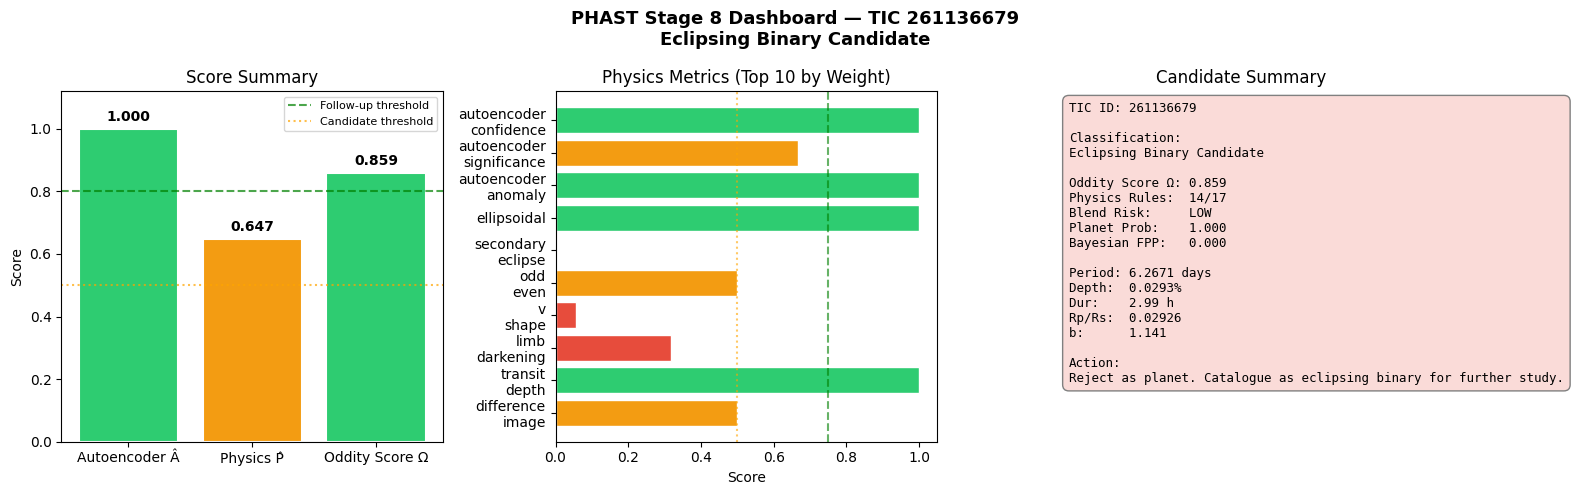

Dashboard saved: /content/drive/MyDrive/exoplanet_pipeline/reports/TIC_261136679_stage8_dashboard.png


In [11]:
# ============================================================
# VISUALIZATION 1: PHAST SCORE DASHBOARD
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"PHAST Stage 8 Dashboard — TIC {tic_id}\n{stage8_classification}",
    fontsize=13, fontweight="bold"
)

# Panel 1: Score Summary Bar Chart
labels = ["Autoencoder Â", "Physics P̂", "Oddity Score Ω"]
values = [autoencoder_score, physics_only_score, oddity_score]
colors = []
for v in values:
    if v >= 0.80:
        colors.append("#2ecc71")   # green
    elif v >= 0.50:
        colors.append("#f39c12")   # orange
    else:
        colors.append("#e74c3c")   # red

bars = axes[0].bar(labels, values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].axhline(0.80, linestyle="--", color="green", alpha=0.7, label="Follow-up threshold")
axes[0].axhline(0.50, linestyle=":",  color="orange", alpha=0.7, label="Candidate threshold")
for i, v in enumerate(values):
    axes[0].text(i, v + 0.025, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel("Score")
axes[0].set_title("Score Summary")
axes[0].legend(fontsize=8)

# Panel 2: Physics Metrics Bar Chart (top 10 by weight)
sorted_metrics = sorted(
    physics_metrics.items(),
    key=lambda x: metric_weights.get(x[0], 1),
    reverse=True
)[:10]

m_names  = [m[0].replace("_", "\n") for m in sorted_metrics]
m_scores = [float(m[1]) for m in sorted_metrics]
m_colors = ["#2ecc71" if s >= 0.75 else "#f39c12" if s >= 0.50 else "#e74c3c" for s in m_scores]

axes[1].barh(m_names, m_scores, color=m_colors, edgecolor="white")
axes[1].axvline(0.75, linestyle="--", color="green", alpha=0.6)
axes[1].axvline(0.50, linestyle=":",  color="orange", alpha=0.6)
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel("Score")
axes[1].set_title("Physics Metrics (Top 10 by Weight)")

# Panel 3: Classification Summary Text Panel
axes[2].axis("off")
summary_text = (
    f"TIC ID: {tic_id}\n\n"
    f"Classification:\n{stage8_classification}\n\n"
    f"Oddity Score Ω: {oddity_score:.3f}\n"
    f"Physics Rules:  {n_passed}/{n_total}\n"
    f"Blend Risk:     {blend_risk_level}\n"
    f"Planet Prob:    {planet_probability:.3f}\n"
    f"Bayesian FPP:   {bayesian_fpp:.3f}\n\n"
    f"Period: {period:.4f} days\n"
    f"Depth:  {depth_pct:.4f}%\n"
    f"Dur:    {duration_hours:.2f} h\n"
    f"Rp/Rs:  {rp_rs:.5f}\n"
    f"b:      {impact_parameter:.3f}\n\n"
    f"Action:\n{recommended_action}"
)
bbox_color = (
    "#d5f5e3" if "Planet" in stage8_classification
    else "#fdebd0" if "Needs" in stage8_classification
    else "#fadbd8"
)
axes[2].text(
    0.05, 0.97, summary_text,
    transform=axes[2].transAxes,
    fontsize=9, verticalalignment="top", fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor=bbox_color, edgecolor="gray")
)
axes[2].set_title("Candidate Summary")

plt.tight_layout()

plot_path = os.path.join(REPORT_DIR, f"TIC_{tic_id}_stage8_dashboard.png")
plt.savefig(plot_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Dashboard saved: {plot_path}")

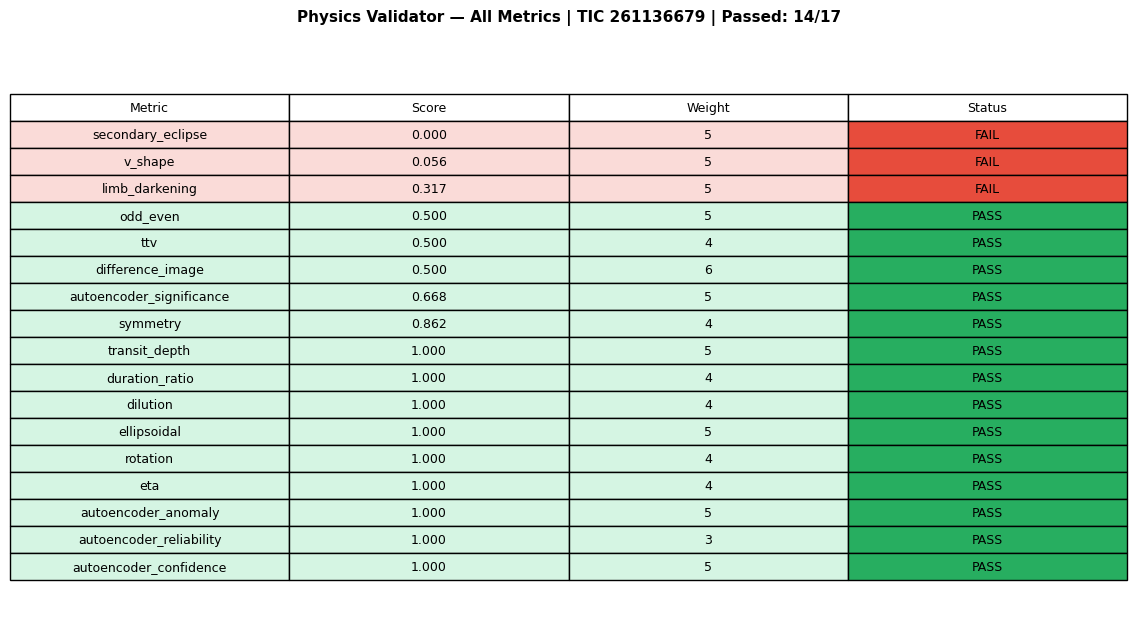

Physics table saved: /content/drive/MyDrive/exoplanet_pipeline/reports/TIC_261136679_physics_table.png


In [12]:
# ============================================================
# VISUALIZATION 2: PASS/FAIL PHYSICS RULES TABLE
# ============================================================

fig, ax = plt.subplots(figsize=(12, max(4, n_total * 0.38)))
ax.axis("off")

table_data = []
cell_colors = []

for metric, score in sorted(physics_metrics.items(), key=lambda x: x[1]):
    score  = float(np.clip(score, 0, 1))
    weight = metric_weights.get(metric, 1)
    status = "PASS" if score >= PASS_THRESHOLD else "FAIL"

    table_data.append([metric, f"{score:.3f}", str(weight), status])

    row_color = (
        ["#d5f5e3", "#d5f5e3", "#d5f5e3", "#27ae60"]
        if status == "PASS"
        else ["#fadbd8", "#fadbd8", "#fadbd8", "#e74c3c"]
    )
    cell_colors.append(row_color)

col_labels = ["Metric", "Score", "Weight", "Status"]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellColours=cell_colors,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.4, 1.4)

ax.set_title(
    f"Physics Validator — All Metrics | TIC {tic_id} | Passed: {n_passed}/{n_total}",
    fontsize=11, fontweight="bold", pad=20
)

plt.tight_layout()
table_path = os.path.join(REPORT_DIR, f"TIC_{tic_id}_physics_table.png")
plt.savefig(table_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Physics table saved: {table_path}")

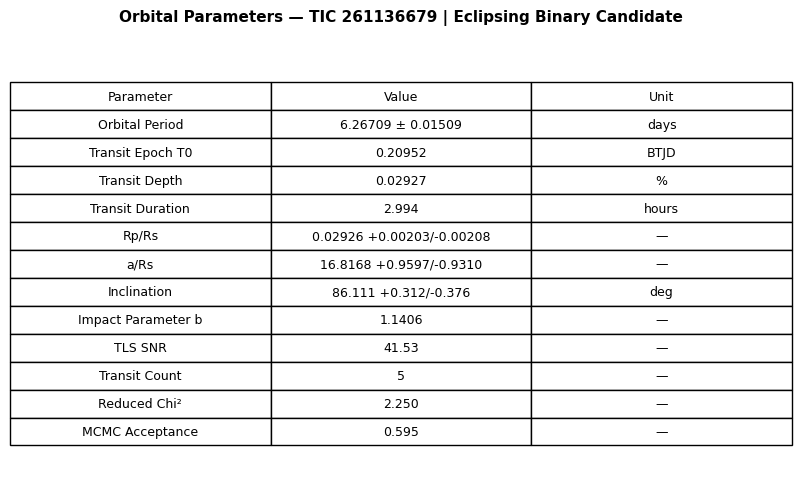

Parameter table saved: /content/drive/MyDrive/exoplanet_pipeline/reports/TIC_261136679_orbital_parameters.png


In [13]:
# ============================================================
# VISUALIZATION 3: ORBITAL PARAMETER SUMMARY
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))
ax.axis("off")

param_data = [
    ["Orbital Period",    f"{period:.5f} ± {period_err:.5f}",  "days"],
    ["Transit Epoch T0",  f"{t0:.5f}",                         "BTJD"],
    ["Transit Depth",     f"{depth_pct:.5f}",                   "%"],
    ["Transit Duration",  f"{duration_hours:.3f}",              "hours"],
    ["Rp/Rs",             f"{rp_rs:.5f} +{rp_rs_upper:.5f}/-{rp_rs_lower:.5f}", "—"],
    ["a/Rs",              f"{a_rs:.4f} +{a_rs_upper:.4f}/-{a_rs_lower:.4f}",    "—"],
    ["Inclination",       f"{inclination:.3f} +{inclination_upper:.3f}/-{inclination_lower:.3f}", "deg"],
    ["Impact Parameter b",f"{impact_parameter:.4f}",            "—"],
    ["TLS SNR",           f"{snr_tls:.2f}",                     "—"],
    ["Transit Count",     f"{transit_count}",                   "—"],
    ["Reduced Chi²",      f"{reduced_chi2:.3f}",                "—"],
    ["MCMC Acceptance",   f"{acceptance_fraction:.3f}",         "—"],
]

param_table = ax.table(
    cellText=param_data,
    colLabels=["Parameter", "Value", "Unit"],
    loc="center",
    cellLoc="center"
)
param_table.auto_set_font_size(False)
param_table.set_fontsize(9)
param_table.scale(1.5, 1.5)

ax.set_title(
    f"Orbital Parameters — TIC {tic_id} | {stage8_classification}",
    fontsize=11, fontweight="bold", pad=20
)

plt.tight_layout()
params_path = os.path.join(REPORT_DIR, f"TIC_{tic_id}_orbital_parameters.png")
plt.savefig(params_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Parameter table saved: {params_path}")

In [14]:
# ============================================================
# SAVE STAGE 8 OUTPUT PKL
# ============================================================

stage8_output = {

    # --- Identity ---
    "tic_id": tic_id,
    "timestamp": timestamp,

    # --- Final Classification ---
    "classification": stage8_classification,
    "classification_reason": classification_reason,
    "recommended_action": recommended_action,

    # --- Scores ---
    "oddity_score": oddity_score,
    "autoencoder_score": autoencoder_score,
    "physics_only_score": physics_only_score,
    "physics_score_stage5": physics_score,
    "planet_probability": planet_probability,
    "bayesian_fpp": bayesian_fpp,
    "approx_fpp": approx_fpp,
    "confidence": confidence,

    # --- Weighting ---
    "weighting_mode": weighting_mode,
    "autoencoder_weight": autoencoder_weight,
    "physics_weight": physics_weight,

    # --- Physics Rules ---
    "n_rules_passed": n_passed,
    "n_rules_total": n_total,
    "rules_passed": rules_passed,
    "rules_failed": rules_failed,
    "physics_metrics": physics_metrics,
    "metric_weights": metric_weights,

    # --- Blend / Pixel ---
    "blend_risk_level": blend_risk_level,
    "blend_risk_flag": blend_risk_flag,
    "centroid_shift": centroid_shift,
    "centroid_score": centroid_score,
    "pixel_score": pixel_score,
    "tpf_available": tpf_available,

    # --- Autoencoder ---
    "autoencoder_reliable": autoencoder_reliable,
    "variability_class": variability_class,

    # --- Orbital Parameters ---
    "period": period,
    "period_err": period_err,
    "t0": t0,
    "duration": duration,
    "duration_hours": duration_hours,
    "transit_depth": transit_depth,
    "depth_pct": depth_pct,
    "rp_rs": rp_rs,
    "rp_rs_lower": rp_rs_lower,
    "rp_rs_upper": rp_rs_upper,
    "a_rs": a_rs,
    "a_rs_lower": a_rs_lower,
    "a_rs_upper": a_rs_upper,
    "inclination": inclination,
    "inclination_lower": inclination_lower,
    "inclination_upper": inclination_upper,
    "impact_parameter": impact_parameter,
    "snr_tls": snr_tls,
    "transit_count": transit_count,

    # --- Model Quality ---
    "reduced_chi2": reduced_chi2,
    "rmse": rmse,
    "acceptance_fraction": acceptance_fraction,

    # --- Narrative ---
    "strengths": strengths,
    "concerns": concerns,
    "stage6_warnings": stage6_warnings,
    "report_text": report_text,

    # --- File Paths ---
    "report_txt_path": report_path,
    "dashboard_png_path": plot_path,
    "physics_table_path": table_path,
    "params_table_path": params_path,
}

with open(STAGE8_PATH, "wb") as f:
    pickle.dump(stage8_output, f, protocol=pickle.HIGHEST_PROTOCOL)

print("=" * 60)
print("STAGE 8 OUTPUT SAVED")
print("=" * 60)
print(f"PKL  : {STAGE8_PATH}")
print(f"TXT  : {report_path}")
print(f"PNG  : {plot_path}")

STAGE 8 OUTPUT SAVED
PKL  : /content/drive/MyDrive/exoplanet_pipeline/data/stage8_output.pkl
TXT  : /content/drive/MyDrive/exoplanet_pipeline/reports/TIC_261136679_candidate_report.txt
PNG  : /content/drive/MyDrive/exoplanet_pipeline/reports/TIC_261136679_stage8_dashboard.png


In [15]:
# ============================================================
# VERIFY SAVED OUTPUT
# ============================================================

with open(STAGE8_PATH, "rb") as f:
    saved = pickle.load(f)

print("Stage 8 PKL keys:", list(saved.keys()))
print()
print(f"TIC ID              : {saved['tic_id']}")
print(f"Classification      : {saved['classification']}")
print(f"Oddity Score Ω      : {saved['oddity_score']:.3f}")
print(f"Physics Rules Passed: {saved['n_rules_passed']}/{saved['n_rules_total']}")
print(f"Failed Rules        : {[r[0] for r in saved['rules_failed']]}")
print(f"Period              : {saved['period']:.5f} days")
print(f"Transit Depth       : {saved['depth_pct']:.4f}%")
print(f"Duration            : {saved['duration_hours']:.3f} hours")
print(f"Blend Risk          : {saved['blend_risk_level']}")
print(f"Recommended Action  : {saved['recommended_action']}")

Stage 8 PKL keys: ['tic_id', 'timestamp', 'classification', 'classification_reason', 'recommended_action', 'oddity_score', 'autoencoder_score', 'physics_only_score', 'physics_score_stage5', 'planet_probability', 'bayesian_fpp', 'approx_fpp', 'confidence', 'weighting_mode', 'autoencoder_weight', 'physics_weight', 'n_rules_passed', 'n_rules_total', 'rules_passed', 'rules_failed', 'physics_metrics', 'metric_weights', 'blend_risk_level', 'blend_risk_flag', 'centroid_shift', 'centroid_score', 'pixel_score', 'tpf_available', 'autoencoder_reliable', 'variability_class', 'period', 'period_err', 't0', 'duration', 'duration_hours', 'transit_depth', 'depth_pct', 'rp_rs', 'rp_rs_lower', 'rp_rs_upper', 'a_rs', 'a_rs_lower', 'a_rs_upper', 'inclination', 'inclination_lower', 'inclination_upper', 'impact_parameter', 'snr_tls', 'transit_count', 'reduced_chi2', 'rmse', 'acceptance_fraction', 'strengths', 'concerns', 'stage6_warnings', 'report_text', 'report_txt_path', 'dashboard_png_path', 'physics_tabl